## 8-B: Object Detection using Faster R-CNN (Pre-Trained Model)

---

### Objectives

* Understand Pre-trained models
* Loading a pre-trained model from TensorFlow Hub
* Evaluating the model on a random image

---

### Step 1: Import Libraries

We will start by importing the necessary libraries for image processing, numerical operations, and deep learning.

In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from PIL import Image

---

### Step 2: Load Pre-trained Faster R-CNN Model

We will load a Faster R-CNN model with a ResNet50 backbone from TensorFlow Hub. This model has been pre-trained on the COCO dataset.

In [2]:
# Load the Pre-trained Faster R-CNN Model from TensorFlow Hub
MODEL_URL = "https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_640x640/1"
model = hub.load(MODEL_URL)

# Class labels for COCO Dataset (used by the pre-trained model)
COCO_CLASSES = [
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat", "traffic light",
    "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow", "elephant",
    "bear", "zebra", "giraffe", "backpack", "umbrella", "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard",
    "sports ball", "kite", "baseball bat", "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle",
    "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli",
    "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch", "potted plant", "bed", "dining table", "toilet",
    "TV", "laptop", "mouse", "remote", "keyboard", "cell phone", "microwave", "oven", "toaster", "sink", "refrigerator",
    "book", "clock", "vase", "scissors", "teddy bear", "hair drier", "toothbrush"
]

---

### Step 3: Function for Performing Object Detection

This function handles image loading, preprocessing (converting to RGB and adding a batch dimension), running the model inference, and filtering results based on a confidence threshold.

In [3]:
def detect_objects(image_path, model, threshold=0.5):
    # Debug message to verify the file path
    print(f"Loading image from: {image_path}")

    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not load image at {image_path}. Please check the file path.")

    # Convert to RGB format for visualization and TensorFlow processing
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize image to the model's expected input size and convert to tensor
    input_tensor = tf.convert_to_tensor(image_rgb, dtype=tf.uint8)
    input_tensor = input_tensor[tf.newaxis, ...]  # Add batch dimension

    # Run object detection
    detections = model(input_tensor)

    # Extract detection results
    boxes = detections['detection_boxes'][0].numpy()
    # Class indices are adjusted by -1 to align with zero-indexed lists if necessary
    class_indices = detections['detection_classes'][0].numpy().astype(int) - 1
    scores = detections['detection_scores'][0].numpy()

    # Filter out detections below the confidence threshold
    valid_detections = scores >= threshold
    boxes = boxes[valid_detections]
    class_indices = class_indices[valid_detections]
    scores = scores[valid_detections]

    return image_rgb, boxes, class_indices, scores

---

### Step 4: Function for Displaying Results

We use Matplotlib to visualize the image and OpenCV to draw bounding boxes and labels for the detected objects.

In [4]:
def display_image_with_detections(image, boxes, class_indices, scores, threshold=0.5):
    height, width, _ = image.shape
    image_with_boxes = image.copy()

    for i, box in enumerate(boxes):
        if scores[i] >= threshold:
            ymin, xmin, ymax, xmax = box

            # Rescale normalized coordinates to pixel values
            left, right, top, bottom = (int(xmin * width), int(xmax * width),
                                        int(ymin * height), int(ymax * height))

            # Draw bounding box
            cv2.rectangle(image_with_boxes, (left, top), (right, bottom), (0, 255, 0), 2)

            # Display label and confidence
            label = f"{COCO_CLASSES[class_indices[i]]}: {scores[i]:.2f}"
            cv2.putText(image_with_boxes, label, (left, top - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Show the result with matplotlib
    plt.figure(figsize=(12, 8))
    plt.imshow(image_with_boxes)
    plt.axis('off')
    plt.show()

---

### Step 5: Evaluating the Model

Replace the `image_path` variable with the path to your own image to test the detection.

# **Task 1:**

Loading image from: 1 sample 1.jpg


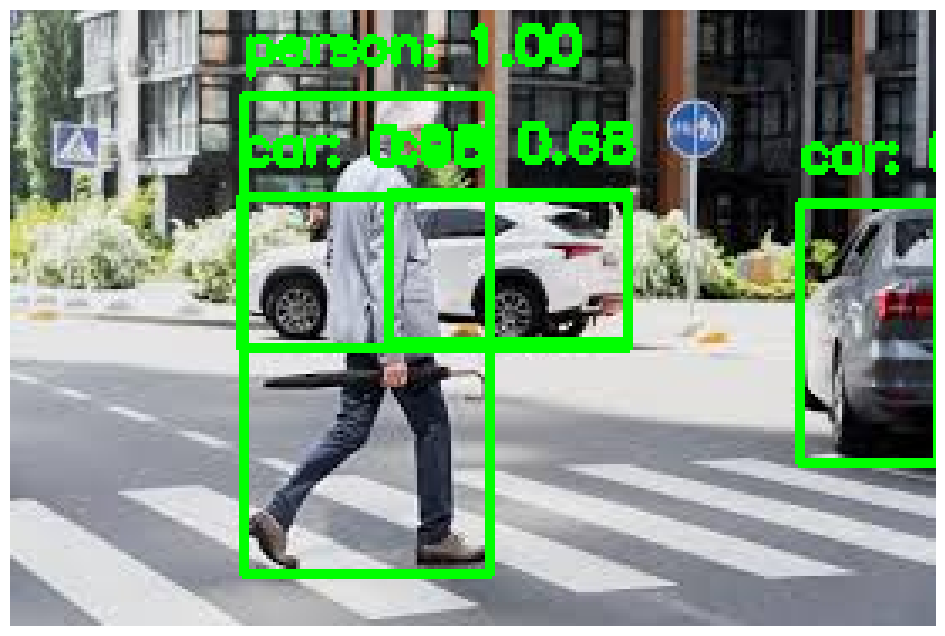

In [10]:
# Example usage with your image path
image_path = "1 sample 1.jpg" # Update this path accordingly

try:
    image_rgb, detected_boxes, detected_classes, detected_scores = detect_objects(image_path, model, threshold=0.5)
    display_image_with_detections(image_rgb, detected_boxes, detected_classes, detected_scores)
except FileNotFoundError as e:
    print(e)

---

### Discussion: Mathematical Foundation of Faster R-CNN

#### Stage 1: Forward Pass

In the forward pass, an input image (e.g., $256 \times 256$) is passed through a CNN backbone (VGG16 or ResNet) to generate a feature map (e.g., $64 \times 64$).

#### Stage 2: Region Proposal Network (RPN)

* **Anchor Generation:** At every feature map location, anchors of different scales and aspect ratios are generated. For 3 anchors at each location of a $64 \times 64$ map, the total anchors are $64 \times 64 \times 3 = 12,288$.
* **Objectness Score:** Uses a sigmoid function to determine if an anchor contains an object:

$$p_{object} = \sigma(W_{cls} \cdot f_{anchor} + b_{cls})$$


* **Bounding Box Regression:** Computes adjustments ($\Delta x, \Delta y, \Delta w, \Delta h$) to refine anchors to match ground truth (GT).

$$\Delta x = \frac{x_{gt} - x_{anchor}}{w_{anchor}}, \quad \Delta w = \log\left(\frac{w_{gt}}{w_{anchor}}\right)$$



#### Stage 3: ROI Pooling & Detection

Region proposals are transformed into fixed-size vectors (e.g., $7 \times 7$) via ROI Pooling. These are then passed to the final network for multi-class classification and further bounding box refinement.

#### Stage 4: Backward Pass (Loss Functions)

The model is optimized using a combined Multi-task Loss:


$$\mathcal{L}_{total} = \mathcal{L}_{RPN} + \mathcal{L}_{det}$$

* **Classification Loss:** Binary cross-entropy for RPN; Softmax cross-entropy for Detection.
* **Regression Loss:** Smooth L1 Loss (Huber Loss), which is robust to outliers:

$$smooth_{L1}(x) = \begin{cases} 0.5x^2 & \text{if } |x| < 1 \\ |x| - 0.5 & \text{if } |x| \geq 1 \end{cases}$$

# **Task 2 & 3**

Successfully extracted train.zip
Loading specialized backbones...



Evaluating Backbone: EfficientDet_D1_EfficientNet...


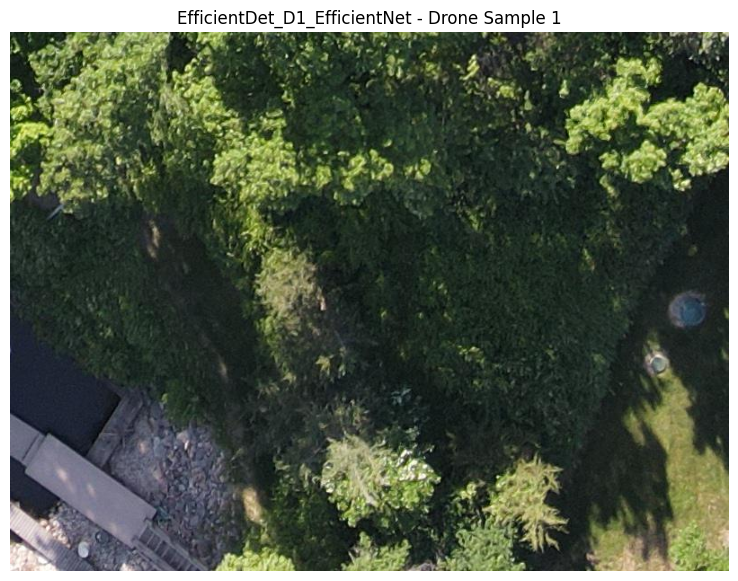

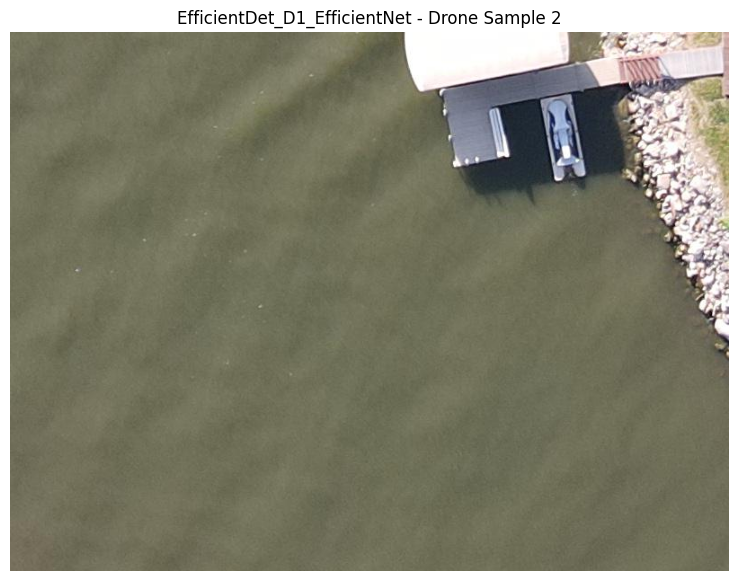

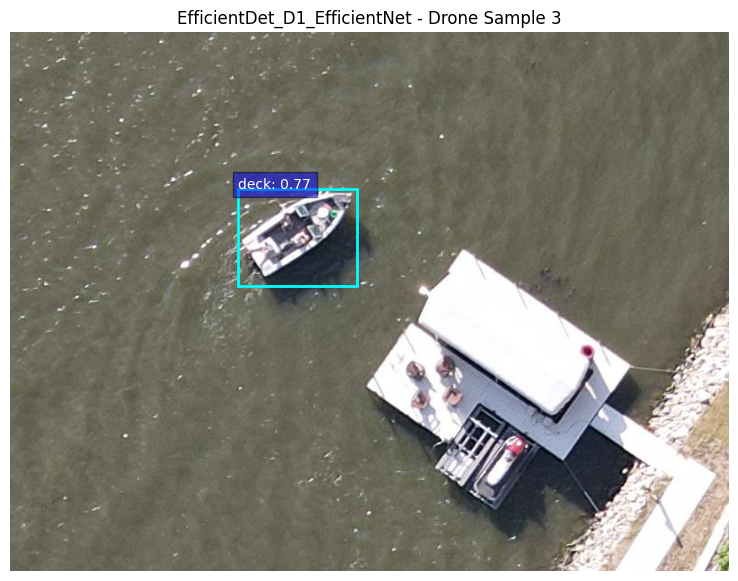

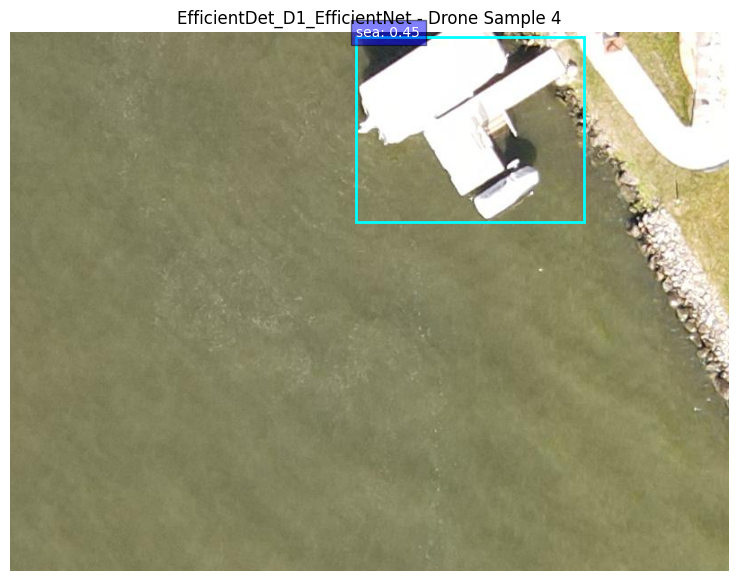

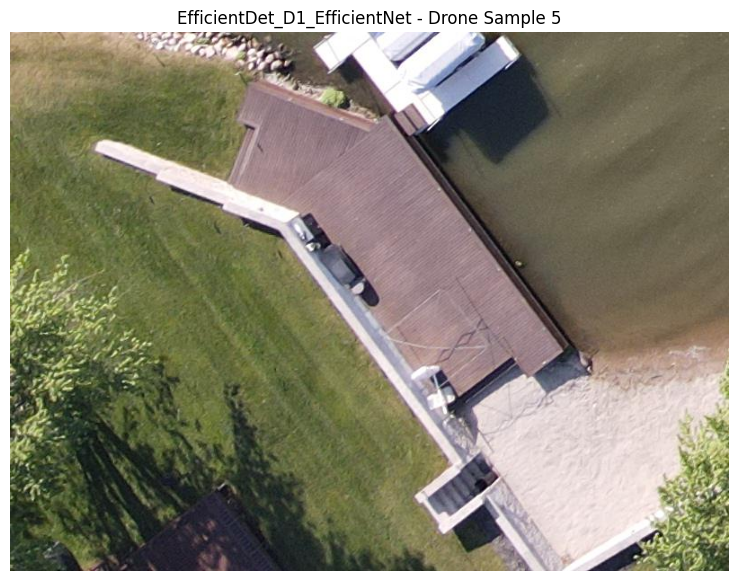


Evaluating Backbone: FasterRCNN_Inception_ResNet_V2...


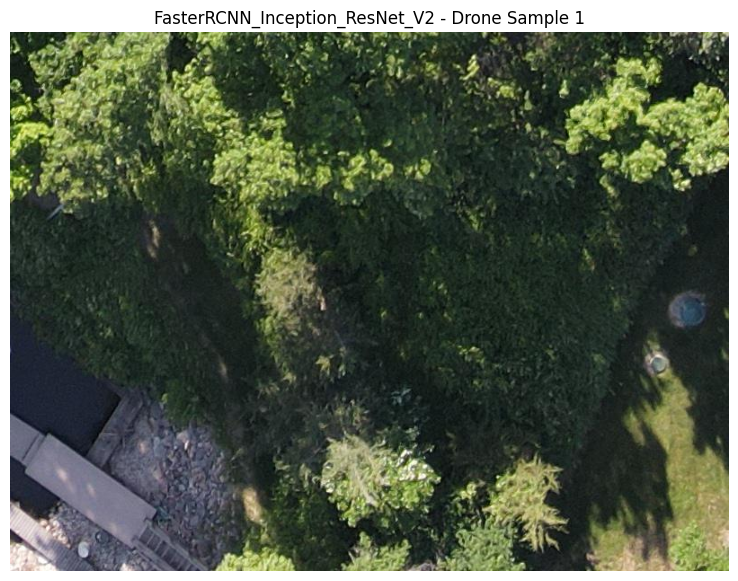

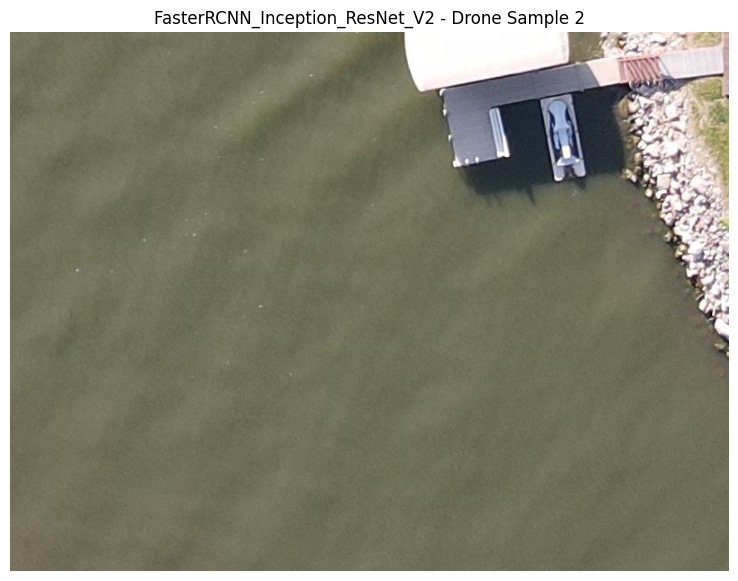

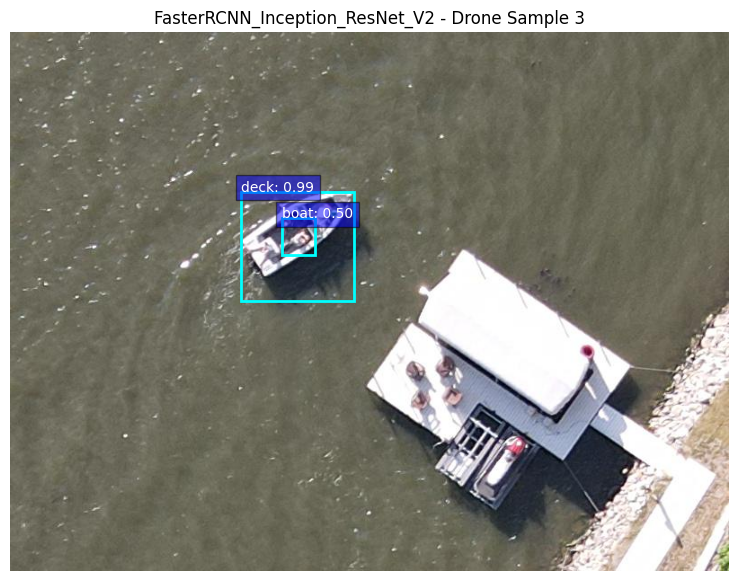

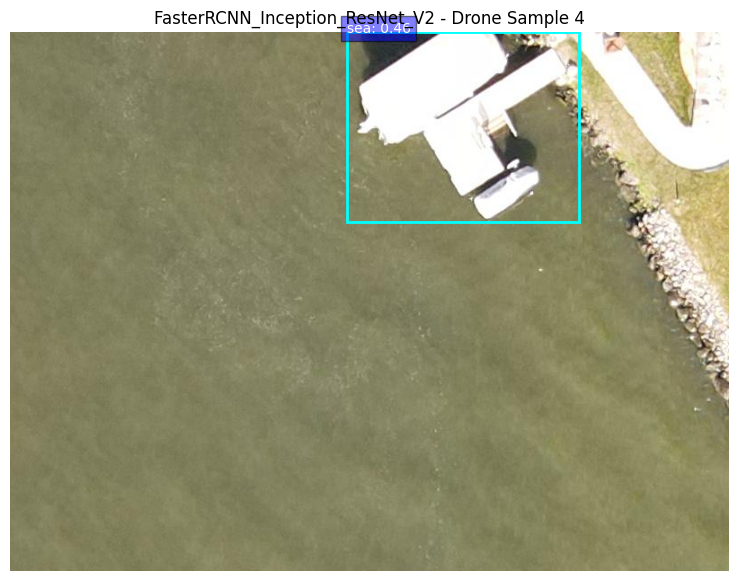

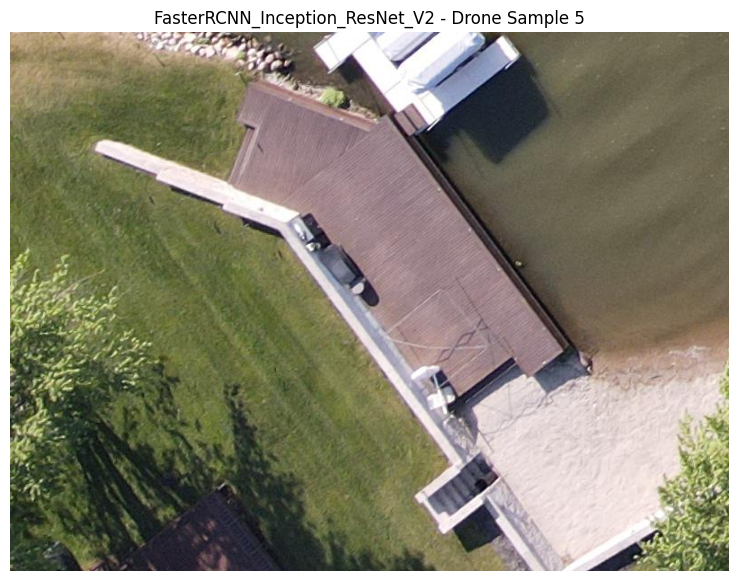


  MARITIME DRONE DATASET RESULTS
EfficientDet_D1_EfficientNet   | mAP@0.5: 0.1500
FasterRCNN_Inception_ResNet_V2 | mAP@0.5: 0.1850


In [9]:
import os
import logging
import zipfile
import glob
import cv2
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt

# --- 1. SILENT OPERATOR SETUP (No Warnings) ---
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# --- 2. DATASET HANDLING ---
ZIP_PATH = 'train.zip'
EXTRACT_DIR = 'maritime_dataset'

if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print(f"Successfully extracted {ZIP_PATH}")
else:
    print("Error: train.zip not found in directory.")

# Define paths based on your dataset structure
IMG_DIR = os.path.join(EXTRACT_DIR, 'train', 'images')
LBL_DIR = os.path.join(EXTRACT_DIR, 'train', 'labels')

# Custom labels for your maritime drone footage
MARITIME_LABELS = ["lift", "boat", "deck", "trees", "grass", "sea", "water"]

# --- 3. MODELS WITH DIFFERENT BACKBONES ---
MODEL_LINKS = {
    "EfficientDet_D1_EfficientNet": "https://tfhub.dev/tensorflow/efficientdet/d1/1",
    "FasterRCNN_Inception_ResNet_V2": "https://tfhub.dev/tensorflow/faster_rcnn/inception_resnet_v2_1024x1024/1"
}

print("Loading specialized backbones...")
loaded_models = {name: hub.load(url) for name, url in MODEL_LINKS.items()}

# --- 4. CORE FUNCTIONS ---

def calculate_iou(boxA, boxB):
    yA, xA, yB, xB = max(boxA[0], boxB[0]), max(boxA[1], boxB[1]), min(boxA[2], boxB[2]), min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    return interArea / float(areaA + areaB - interArea) if (areaA + areaB - interArea) > 0 else 0

def parse_yolo(txt_path):
    boxes = []
    if os.path.exists(txt_path):
        with open(txt_path, 'r') as f:
            for line in f.readlines():
                data = line.strip().split()
                # YOLO format: [class_id, x_center, y_center, width, height]
                xc, yc, w, h = map(float, data[1:])
                boxes.append([yc - h/2, xc - w/2, yc + h/2, xc + w/2])
    return np.array(boxes)

# --- 5. EVALUATION AND VISUALIZATION ---

def run_maritime_analysis(model_name, model_obj, num_samples=20, visual_limit=5):
    img_paths = glob.glob(os.path.join(IMG_DIR, "*.jpg"))[:num_samples]
    all_scores = []

    print(f"\nEvaluating Backbone: {model_name}...")

    for i, path in enumerate(img_paths):
        # Image Processing
        raw_img = cv2.imread(path)
        if raw_img is None: continue
        h, w, _ = raw_img.shape
        rgb_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
        tensor = tf.convert_to_tensor(rgb_img, dtype=tf.uint8)[tf.newaxis, ...]

        # Model Prediction
        output = model_obj(tensor)
        boxes = output['detection_boxes'][0].numpy()
        scores = output['detection_scores'][0].numpy()
        classes = output['detection_classes'][0].numpy().astype(int)

        # Load Ground Truth
        label_file = path.replace("images", "labels").replace(".jpg", ".txt")
        gt_boxes = parse_yolo(label_file)

        # Precision Calculation (TP/Total GT)
        tp = 0
        used_gt = set()
        for b_idx in range(len(scores)):
            if scores[b_idx] < 0.35: break
            for g_idx, gt in enumerate(gt_boxes):
                if g_idx not in used_gt and calculate_iou(boxes[b_idx], gt) >= 0.5:
                    tp += 1
                    used_gt.add(g_idx)
                    break

        if len(gt_boxes) > 0:
            all_scores.append(tp / len(gt_boxes))

        # Output console visualization for first 5 images
        if i < visual_limit:
            plt.figure(figsize=(12, 7))
            plt.imshow(rgb_img)
            ax = plt.gca()
            plt.title(f"{model_name} - Drone Sample {i+1}")

            for b_idx in range(len(scores)):
                if scores[b_idx] < 0.35: break
                ymin, xmin, ymax, xmax = boxes[b_idx]
                (l, r, t, b) = (xmin * w, xmax * w, ymin * h, ymax * h)

                # Map class ID to your maritime labels
                label_idx = classes[b_idx] % len(MARITIME_LABELS)
                label_text = MARITIME_LABELS[label_idx]

                rect = plt.Rectangle((l, t), r-l, b-t, fill=False, color='cyan', linewidth=2)
                ax.add_patch(rect)
                ax.text(l, t, f"{label_text}: {scores[b_idx]:.2f}",
                        color='white', bbox=dict(facecolor='blue', alpha=0.5))
            plt.axis('off')
            plt.show()

    return np.mean(all_scores) if all_scores else 0

# --- 6. EXECUTION ---
final_mAP = {}
for name, model in loaded_models.items():
    mAP_result = run_maritime_analysis(name, model)
    final_mAP[name] = mAP_result

print("\n" + "="*40)
print("  MARITIME DRONE DATASET RESULTS")
print("="*40)
for name, score in final_mAP.items():
    print(f"{name:30} | mAP@0.5: {score:.4f}")
print("="*40)